In [1]:

%load_ext autoreload
%autoreload 2

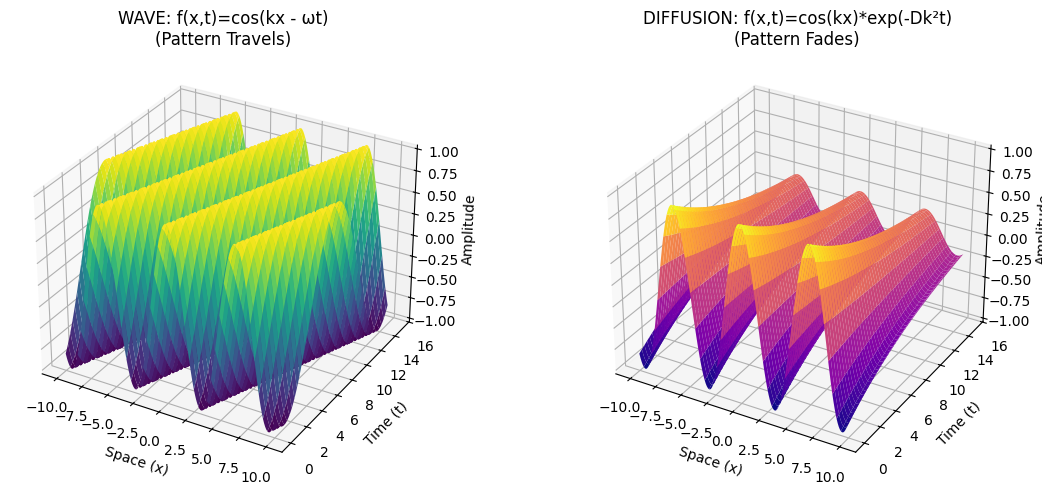

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
k = 1.0        # spatial frequency (rad/m)
omega = 0.5    # temporal frequency (rad/s) - REAL for wave
D = 0.1        # diffusion coefficient (for comparison)

# Create space-time grid
x = np.linspace(-10, 10, 200)
t = np.linspace(0, 15, 150)
X, T = np.meshgrid(x, t)

# Calculate f(x,t) for a WAVE (real omega)
F_wave = np.cos(k * X - omega * T)

# Calculate f(x,t) for DIFFUSION (imaginary omega -> decay)
# This is a single mode: initial pattern cos(kx) that decays
F_diff = np.cos(k * X) * np.exp(-D * k**2 * T)

# Plot the Wave
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, T, F_wave, cmap='viridis', edgecolor='none')
ax1.set_title('WAVE: f(x,t)=cos(kx - ωt)\n(Pattern Travels)')
ax1.set_xlabel('Space (x)')
ax1.set_ylabel('Time (t)')
ax1.set_zlabel('Amplitude')

# Plot the Diffusion
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, T, F_diff, cmap='plasma', edgecolor='none')
ax2.set_title('DIFFUSION: f(x,t)=cos(kx)*exp(-Dk²t)\n(Pattern Fades)')
ax2.set_xlabel('Space (x)')
ax2.set_ylabel('Time (t)')
ax2.set_zlabel('Amplitude')

plt.tight_layout()
plt.show()

In [2]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import json

# Import custom modules
from src.config.storage import SimulationStorage
from src.config.path import RESULTS_DIR, CLUSTER_OUTPUT_DIR

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Imports successful")
print(f"Project root: {project_root}")

Source Directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis
Output Directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis
HAMNUCRET Data Directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/hamnucret_data
✓ Imports successful
Project root: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis


In [3]:
def load_summary_table(folder: Path) -> pd.DataFrame | None:
    """Load all summary TSV files from a result directory."""
    summary_dir = folder / "summaries"
    files = sorted(summary_dir.glob("*.tsv"))
    if not files:
        print(f"⚠ No summary TSV files in {folder.name}")
        return None
    frames = []
    for f in files:
        df = pd.read_csv(f, sep="\t")
        df["file_id"] = f.stem
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def load_survival_curves_lazy(folder: Path) -> pl.LazyFrame | None:
    """
    Load survival curves from a result directory using Polars lazy loading.
    Returns a LazyFrame with columns: tau_grid, survival, file_id
    Memory-efficient - data is not loaded until .collect() is called.
    """
    survival_dir = folder / "survivals"
    survival_files = sorted(survival_dir.glob("*.parquet"))
    
    if not survival_files:
        print(f"⚠ No survival files in {folder.name}")
        return None
    
    # Load each file and add file_id - stay lazy!
    dfs = []
    for f in survival_files:
        df = pl.scan_parquet(f).with_columns(
            pl.lit(f.stem).alias('file_id')
        )
        dfs.append(df)
    
    # Concatenate lazily - DO NOT COLLECT YET
    return pl.concat(dfs)


def compute_survival_statistics(survival_lazy: pl.LazyFrame, file_ids: list[str]) -> dict:
    """
    Compute mean, std, median survival curves for each file_id.
    Returns dict mapping file_id -> {tau_grid, mean, std, median, n}
    """
    survival_by_file_id = {}
    
    for fid in file_ids:
        # Filter lazily and keep only needed columns
        surv_fid_lazy = (
            survival_lazy
            .filter(pl.col("file_id") == fid)
            .select(["tau_grid", "survival"])
        )
        surv_fid = surv_fid_lazy.collect()
        
        if surv_fid.height == 0:
            print(f"  ⚠ {fid}: no trajectories")
            continue
        
        # Common time grid from first row
        first_row = surv_fid.row(0, named=True)
        t = np.asarray(first_row["tau_grid"])
        n_t = t.shape[0]

        # Convert survival column (list per row) to a 2D NumPy array
        surv_lists = surv_fid["survival"].to_list()          # list[list[float]]
        S = np.array(surv_lists, dtype=float)                # shape: (n_traj, n_t)

        if S.shape[1] != n_t:
            print(f"  ⚠ {fid}: mismatch S.shape[1]={S.shape[1]} vs tau_grid={n_t}")
        
        # Element-wise statistics across trajectories (axis=0)
        S_mean = np.nanmean(S, axis=0)
        S_std = np.nanstd(S, axis=0)
        S_median = np.nanmedian(S, axis=0)
        
        survival_by_file_id[fid] = {
            "tau_grid": t,
            "mean": S_mean,
            "std": S_std,
            "median": S_median,
            "n": surv_fid.height,
        }
        print(f"  ✓ {fid}: {surv_fid.height} trajectories, {n_t} time points")
    
    return survival_by_file_id


def summarize_mfpt(df: pd.DataFrame, k_wrap_val: float) -> pd.DataFrame:
    """
    Compute MFPT statistics per file_id from summary data.
    Returns DataFrame with columns: file_id, n_total, n_valid, n_censored, 
                                    mfpt_mean, mfpt_std, mfpt_median (dimensionless and physical)
    """
    work = df.copy()
    if {"file_id", "nuc_id"}.issubset(work.columns):
        work = work.groupby(["file_id", "nuc_id"], as_index=False)["mfpt"].mean()
    work["mfpt"] = pd.to_numeric(work["mfpt"], errors="coerce")
    work["is_valid"] = np.isfinite(work["mfpt"]) & (work["mfpt"] > 0)
    stats = []
    for fid, grp in work.groupby("file_id"):
        valid = grp.loc[grp["is_valid"], "mfpt"]
        entry = {
            "file_id": fid,
            "n_total": len(grp),
            "n_valid": len(valid),
            "n_censored": len(grp) - len(valid),
            "mfpt_mean": valid.mean() if len(valid) else np.nan,
            "mfpt_std": valid.std(ddof=1) if len(valid) > 1 else np.nan,
            "mfpt_median": valid.median() if len(valid) else np.nan,
        }
        stats.append(entry)
    result = pd.DataFrame(stats)
    if np.isfinite(k_wrap_val) and k_wrap_val > 0:
        result["mfpt_mean_phys"] = result["mfpt_mean"] / k_wrap_val
        result["mfpt_std_phys"] = result["mfpt_std"] / k_wrap_val
        result["mfpt_median_phys"] = result["mfpt_median"] / k_wrap_val
    else:
        result["mfpt_mean_phys"] = np.nan
        result["mfpt_std_phys"] = np.nan
        result["mfpt_median_phys"] = np.nan
    return result


def half_life(time, S_mean, level=0.5):
    """
    Calculate half-life (first time t where S(t) <= level).
    Uses linear interpolation between bracketing points.
    Returns np.nan if the curve never reaches the level.
    """
    t = np.asarray(time, dtype=float)
    S = np.asarray(S_mean, dtype=float)

    m = np.isfinite(t) & np.isfinite(S)
    if m.sum() < 2:
        return np.nan
    t, S = t[m], S[m]

    # already below at start
    if S[0] <= level:
        return float(t[0])

    below = np.where(S <= level)[0]
    if below.size == 0:
        return np.nan  # not reached

    j = int(below[0])
    i = j - 1
    if i < 0:
        return float(t[j])

    # linear interpolation
    if S[j] == S[i]:
        return float(t[j])
    frac = (level - S[i]) / (S[j] - S[i])
    return float(t[i] + frac * (t[j] - t[i]))


print("✓ Utility functions defined")

✓ Utility functions defined


## Utility Functions

Define reusable functions for loading and processing Markov results.

# Markov Solver Results Analysis

This notebook loads and analyzes results from the Markov solver:
- **Summary data (TSV)**: Mean First Passage Time (MFPT), half-life, parameters
- **Survival curves (Parquet)**: Time-dependent survival probability S(t)

## Workflow
1. Load data from output directory
2. Explore parameter space
3. Analyze MFPT distributions
4. Plot survival curves (individual and averaged)
5. Compare different conditions

## 1. Configuration

Specify the output directory containing Markov results.

In [4]:
# Configure paths
from src.markov_execution.storage import MarkovStorage

# Option 1: Use cluster output directory
markov_output_dir = CLUSTER_OUTPUT_DIR / "markov_parameter_grid"

# Option 2: Use local output directory
# markov_output_dir = RESULTS_DIR / "local_markov_test"

# Option 3: Specify custom path
# markov_output_dir = Path("/path/to/your/markov/results")

print(f"Markov output directory: {markov_output_dir}")
print(f"Directory exists: {markov_output_dir.exists()}")

# Initialize storage (with index for easy querying)
storage = MarkovStorage(base_dir=markov_output_dir, use_index=True)
storage.rebuild_index()
print(f"✓ Storage initialized")

Markov output directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/cluster_output/markov_parameter_grid
Directory exists: True
Rebuilt index with 10 entries
✓ Storage initialized


/home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/src/markov_execution/storage.py:206: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.index = pd.concat([self.index, pd.DataFrame([new_entry])], ignore_index=True)


## 2. Explore Available Results

Check what parameter combinations are available.

In [5]:
# List all result directories
if markov_output_dir.exists():
    result_dirs = [d for d in markov_output_dir.iterdir() if d.is_dir() and not d.name.startswith('.')]
    print(f"Found {len(result_dirs)} result directories:\n")
    for d in sorted(result_dirs)[:10]:  # Show first 10
        print(f"  • {d.name}")
    if len(result_dirs) > 10:
        print(f"  ... and {len(result_dirs) - 10} more")
else:
    print(f"⚠ Directory {markov_output_dir} does not exist")
    print("Please create results first by running the Markov solver")

Found 10 result directories:

  • k1.0_p0.0_c0.0_tau10000_ode__17e2f8
  • k1.0_p10.0_c0.0_tau10000_ode__7d150a
  • k1.0_p100.0_c0.0_tau10000_ode__5267d0
  • k1.0_p100.0_c4.5_tau10000_ode__816516
  • k1.0_p1000.0_c0.0_tau10000_ode__2d7163
  • k1.0_p1000.0_c4.5_tau10000_ode__a01e3c
  • k1.0_p500.0_c0.0_tau10000_ode__985458
  • k1.0_p500.0_c4.5_tau10000_ode__34a02e
  • k1.0_p5000.0_c0.0_tau10000_ode__ef71b9
  • k1.0_p5000.0_c4.5_tau10000_ode__f7798a


In [6]:
# Check if index exists
index_file = markov_output_dir / "markov_index.csv"

if index_file.exists():
    index_df = pd.read_csv(index_file)
    print(f"✓ Index found with {len(index_df)} entries\n")
    print("Index preview:")
    display(index_df.head(10))
    
    # Show unique parameter values
    print("\n" + "="*80)
    print("Available parameter values:")
    print("="*80)
    for col in ['k_wrap', 'p_conc', 'cooperativity', 'method', 'tau_max']:
        if col in index_df.columns:
            unique_vals = index_df[col].unique()
            print(f"  {col:15s}: {sorted(unique_vals)}")
else:
    print("⚠ Index file not found. You can rebuild it using:")
    print(f"  bash rebuild_markov_index.sh")
    index_df = None

✓ Index found with 10 entries

Index preview:


,directory,k_wrap,tau_max,tau_steps,method,k_bind,k_unbind,p_conc,cooperativity,binding_sites,sparse,dimensionless
0,k1.0_p10.0_c0.0_tau10000_ode__7d150a,1.0,10000.0,1000,ode,1.0,89.7,10.0,0.0,14,False,True
1,k1.0_p500.0_c4.5_tau10000_ode__34a02e,1.0,10000.0,1000,ode,1.0,89.7,500.0,4.5,14,False,True
2,k1.0_p1000.0_c4.5_tau10000_ode__a01e3c,1.0,10000.0,1000,ode,1.0,89.7,1000.0,4.5,14,False,True
3,k1.0_p5000.0_c4.5_tau10000_ode__f7798a,1.0,10000.0,1000,ode,1.0,89.7,5000.0,4.5,14,False,True
4,k1.0_p0.0_c0.0_tau10000_ode__17e2f8,1.0,10000.0,1000,ode,1.0,89.7,0.0,0.0,14,False,True
5,k1.0_p500.0_c0.0_tau10000_ode__985458,1.0,10000.0,1000,ode,1.0,89.7,500.0,0.0,14,False,True
6,k1.0_p100.0_c4.5_tau10000_ode__816516,1.0,10000.0,1000,ode,1.0,89.7,100.0,4.5,14,False,True
7,k1.0_p100.0_c0.0_tau10000_ode__5267d0,1.0,10000.0,1000,ode,1.0,89.7,100.0,0.0,14,False,True
8,k1.0_p5000.0_c0.0_tau10000_ode__ef71b9,1.0,10000.0,1000,ode,1.0,89.7,5000.0,0.0,14,False,True
9,k1.0_p1000.0_c0.0_tau10000_ode__2d7163,1.0,10000.0,1000,ode,1.0,89.7,1000.0,0.0,14,False,True



Available parameter values:
  k_wrap         : [np.float64(1.0)]
  p_conc         : [np.float64(0.0), np.float64(10.0), np.float64(100.0), np.float64(500.0), np.float64(1000.0), np.float64(5000.0)]
  cooperativity  : [np.float64(0.0), np.float64(4.5)]
  method         : ['ode']
  tau_max        : [np.float64(10000.0)]


## 3. Load Results for Specific Parameters

Select a specific parameter combination and load all nucleosome results.

In [7]:
# Select parameters to analyze
target_params = {
    'k_wrap': 1.0,
    'p_conc': 0.0,
    'cooperativity': 0.0,
    'tau_max': 10000,
    'method': 'ode'
}

print("Target parameters:")
for key, val in target_params.items():
    print(f"  {key:15s}: {val}")

# Find matching directory
if index_df is not None:
    # Use index to find matching results
    mask = pd.Series([True] * len(index_df))
    for key, val in target_params.items():
        if key in index_df.columns:
            mask &= (index_df[key] == val)
    
    matching = index_df[mask]
    
    if len(matching) > 0:
        print(f"\n✓ Found {len(matching)} matching parameter set(s)")
        selected_dir = markov_output_dir / matching.iloc[0]['directory']
        print(f"Selected directory: {selected_dir.name}")
    else:
        print("\n⚠ No matching results found")
        selected_dir = None
else:
    # Manually find directory by pattern matching
    print("\nSearching directories manually...")
    selected_dir = None
    for d in result_dirs:
        if all([
            f"k{target_params['k_wrap']:.1f}" in d.name,
            f"p{target_params['p_conc']:.1f}" in d.name,
            f"c{target_params['cooperativity']:.1f}" in d.name,
            target_params['method'] in d.name
        ]):
            selected_dir = d
            print(f"✓ Found: {d.name}")
            break
    
    if selected_dir is None:
        print("⚠ No matching directory found")

Target parameters:
  k_wrap         : 1.0
  p_conc         : 0.0
  cooperativity  : 0.0
  tau_max        : 10000
  method         : ode

✓ Found 1 matching parameter set(s)
Selected directory: k1.0_p0.0_c0.0_tau10000_ode__17e2f8


In [8]:
# Load summary data using reusable function
summary_df = load_summary_table(selected_dir)

if summary_df is not None:
    print(f"✓ Loaded {len(summary_df)} nucleosome results")
    print(f"Found {len(summary_df['file_id'].unique())} unique file_ids\n")
    print("First few entries:")
    display(summary_df.head())
else:
    print("⚠ No summary data found")

✓ Loaded 34163 nucleosome results
Found 2 unique file_ids

First few entries:


,id,subid,mfpt,file_id
0,ENST00000219409.8,2317,inf,bound_001
1,ENST00000219409.8,2896,inf,bound_001
2,ENST00000219439.9,1881,inf,bound_001
3,ENST00000219473.12,1788,inf,bound_001
4,ENST00000219473.12,2325,inf,bound_001


In [9]:
summary_df["file_id"].unique() if summary_df is not None else None

array(['bound_001', 'unbound_001'], dtype=object)

## 4. MFPT Distribution Analysis

Analyze the distribution of Mean First Passage Times across nucleosomes.

In [10]:
# Identify unique file_ids in the current dataset

unique_file_ids = sorted(summary_df['file_id'].unique())
print(f"Found {len(unique_file_ids)} unique file_ids:")
for fid in unique_file_ids:
    count = len(summary_df[summary_df['file_id'] == fid])
    print(f"  • {fid}: {count} nucleosomes")

# Store for later use
file_ids_to_compare = unique_file_ids
print(f"\n✓ Will compare: {file_ids_to_compare}")

Found 2 unique file_ids:
  • bound_001: 16009 nucleosomes
  • unbound_001: 18154 nucleosomes

✓ Will compare: ['bound_001', 'unbound_001']


,file_id,n_total,n_valid,n_censored
0,bound_001,16009,1740,14269
1,unbound_001,18154,11106,7048


/tmp/ipykernel_181101/1880657075.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


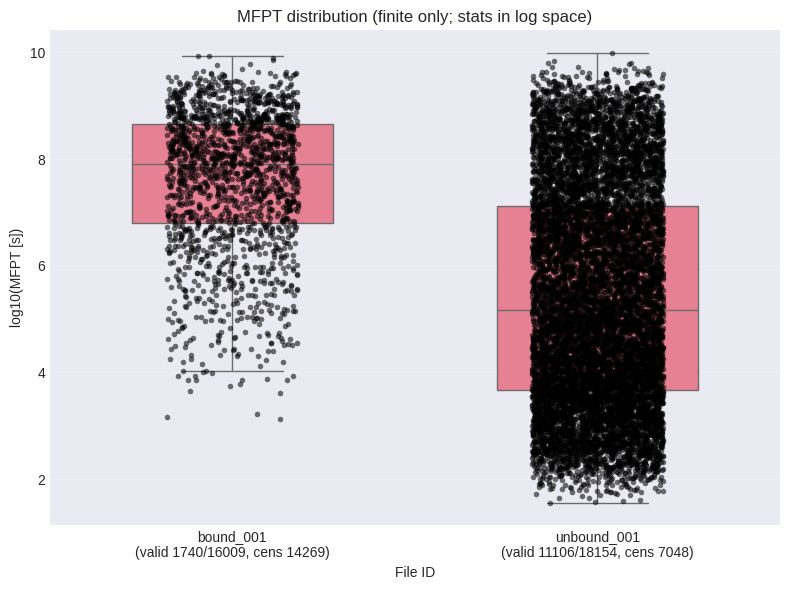

In [11]:
# filepath: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/notebooks/Analyse_Markov_Results.ipynb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

k_wrap = float(target_params.get("k_wrap", 1.0))
tau_max = float(target_params.get("tau_max", np.nan))  # dimensionless
tau_max_phys = (tau_max / k_wrap) if np.isfinite(tau_max) else np.nan

# --- 0) choose "sample": per-nucleosome mean if repeated rows exist ---
df = summary_df.copy()
group_cols = [c for c in ["file_id", "nuc_id"] if c in df.columns]
if group_cols == ["file_id", "nuc_id"]:
    df = df.groupby(group_cols, as_index=False).agg(mfpt=("mfpt", "mean"))

# --- 1) convert, flag censoring, clean ---
df["mfpt_phys"] = pd.to_numeric(df["mfpt"], errors="coerce") / k_wrap
df = df[df["file_id"].isin(file_ids_to_compare)].copy()

df["is_censored"] = ~np.isfinite(df["mfpt_phys"])  # inf or nan
df["is_valid"] = np.isfinite(df["mfpt_phys"]) & (df["mfpt_phys"] > 0)

# counts per file_id
counts = (
    df.groupby("file_id")
      .agg(n_total=("mfpt_phys", "size"),
           n_valid=("is_valid", "sum"),
           n_censored=("is_censored", "sum"))
      .reset_index()
)
display(counts)

# only finite positive values can be log-transformed
dfv = df[df["is_valid"]].copy()
dfv["log10_mfpt"] = np.log10(dfv["mfpt_phys"])

# --- 2) Plot: log-space box + points (quartiles computed in log space) ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.boxplot(
    data=dfv,
    x="file_id",
    y="log10_mfpt",
    showfliers=False,
    width=0.55,
    ax=ax,
)
sns.stripplot(
    data=dfv,
    x="file_id",
    y="log10_mfpt",
    color="k",
    size=4,
    alpha=0.55,
    jitter=0.18,
    ax=ax,
)
ax.set_xlabel("File ID")
ax.set_ylabel("log10(MFPT [s])")
ax.set_title("MFPT distribution (finite only; stats in log space)")
ax.grid(True, axis="y", alpha=0.25)

# annotate censoring per group (so the reader knows what's omitted)
tick_labels = []
for fid in file_ids_to_compare:
    row = counts[counts["file_id"] == fid]
    if len(row) == 1:
        n_tot = int(row["n_total"].iloc[0])
        n_val = int(row["n_valid"].iloc[0])
        n_cen = int(row["n_censored"].iloc[0])
        tick_labels.append(f"{fid}\n(valid {n_val}/{n_tot}, cens {n_cen})")
    else:
        tick_labels.append(fid)
ax.set_xticklabels(tick_labels)

plt.tight_layout()
plt.show()

## 5. Load Survival Curves

Load time-dependent survival probability data from Parquet files.

In [12]:
# Load survival curves using reusable lazy loading function
survival_pl_lazy = load_survival_curves_lazy(selected_dir)

if survival_pl_lazy is not None:
    # Only collect a small sample to show schema and preview
    print("Survival data schema:")
    sample = survival_pl_lazy.head(5).collect()
    print(sample.schema)
    print("\nFirst few rows:")
    print(sample)
else:
    print("⚠ No survival files found")

Survival data schema:
Schema({'id': String, 'subid': Int64, 'tau_grid': List(Float64), 'survival': List(Float64), 'mfpt': Float64, 'mfpt_vec': List(Float64), 'file_id': String})

First few rows:
shape: (5, 7)
┌────────────────────┬───────┬────────────────────┬──────────────┬──────┬──────────────┬───────────┐
│ id                 ┆ subid ┆ tau_grid           ┆ survival     ┆ mfpt ┆ mfpt_vec     ┆ file_id   │
│ ---                ┆ ---   ┆ ---                ┆ ---          ┆ ---  ┆ ---          ┆ ---       │
│ str                ┆ i64   ┆ list[f64]          ┆ list[f64]    ┆ f64  ┆ list[f64]    ┆ str       │
╞════════════════════╪═══════╪════════════════════╪══════════════╪══════╪══════════════╪═══════════╡
│ ENST00000219409.8  ┆ 2317  ┆ [0.0, 10.01001, …  ┆ [1.0, 1.0, … ┆ inf  ┆ [inf, inf, … ┆ bound_001 │
│                    ┆       ┆ 10000.0]           ┆ 1.0]         ┆      ┆ inf]         ┆           │
│ ENST00000219409.8  ┆ 2896  ┆ [0.0, 10.01001, …  ┆ [1.0, 1.0, … ┆ inf  ┆ [inf, inf,

## 6. Plot Survival Curves

Visualize individual and average survival curves.

In [13]:
print("Computing mean survival curves for each file_id...")

# Use reusable function to compute survival statistics
survival_by_file_id = compute_survival_statistics(survival_pl_lazy, file_ids_to_compare)

Computing mean survival curves for each file_id...
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points


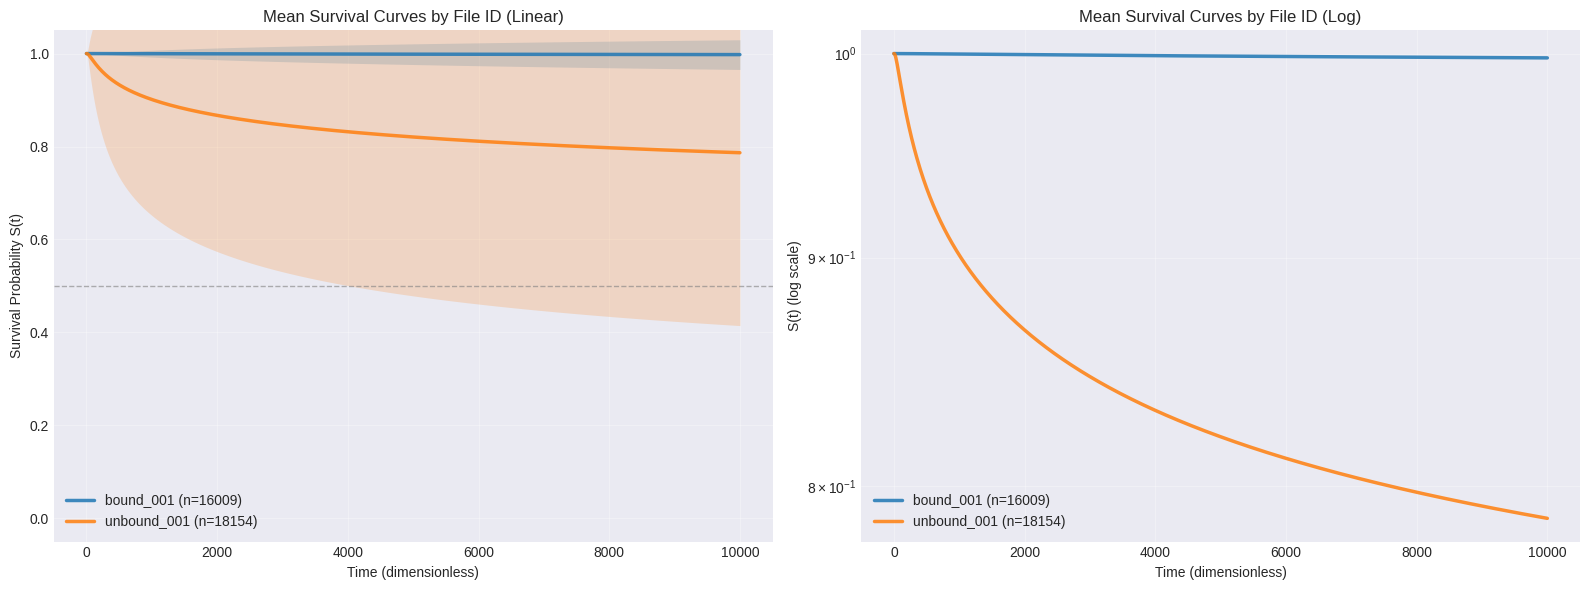


HALF-LIFE COMPARISON (first crossing of S(t) <= 0.5)
bound_001           : t_1/2 = not reached (t_1/2 > 10000.0000 in this window)
unbound_001         : t_1/2 = not reached (t_1/2 > 10000.0000 in this window)

Physical time (k_wrap = 1.00 s^-1):
bound_001           : t_1/2 = not reached (t_1/2 > 10000.0000 s)
unbound_001         : t_1/2 = not reached (t_1/2 > 10000.0000 s)

SURVIVAL CURVE SUMMARY

bound_001
  trajectories (n)          : 16009
  S(0)                      : 1.0000 ± 0.0000
  S(t_max=10000.00)      : 0.9978 ± 0.0319
  Area under S(t)           : 9987.6235 (dimensionless time)
  Time when S(t) ≤ 0.1      : not reached

unbound_001
  trajectories (n)          : 18154
  S(0)                      : 1.0000 ± 0.0000
  S(t_max=10000.00)      : 0.7867 ± 0.3719
  Area under S(t)           : 8349.6188 (dimensionless time)
  Time when S(t) ≤ 0.1      : not reached


In [14]:
# ---------- PLOTTING ----------

# keep only file_ids that actually have survival data
fids = [fid for fid in file_ids_to_compare if fid in survival_by_file_id]
if len(fids) == 0:
    raise ValueError("No survival curves found for the selected file_ids.")

colors = {fid: plt.cm.tab10(i % 10) for i, fid in enumerate(fids)}

def band(ax, t, y, ystd, color, alpha=0.2):
    ax.fill_between(t, y - ystd, y + ystd, color=color, alpha=alpha, linewidth=0)

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(16, 6))

# 1) Mean survival curves (linear + band)
for fid in fids:
    d = survival_by_file_id[fid]
    t, m, s = d["tau_grid"], d["mean"], d["std"]
    c = colors[fid]
    ax_lin.plot(t, m, lw=2.5, color=c, alpha=0.85, label=f"{fid} (n={d['n']})")
    band(ax_lin, t, m, s, c, alpha=0.2)

ax_lin.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.6)
ax_lin.set(xlabel="Time (dimensionless)", ylabel="Survival Probability S(t)",
           title="Mean Survival Curves by File ID (Linear)")
ax_lin.grid(True, alpha=0.3)
ax_lin.set_ylim([-0.05, 1.05])
ax_lin.legend(fontsize=10)

# 2) Mean survival curves (log)
for fid in fids:
    d = survival_by_file_id[fid]
    t, m = d["tau_grid"], d["mean"]
    ax_log.semilogy(t, m + 1e-12, lw=2.5, color=colors[fid], alpha=0.85, label=f"{fid} (n={d['n']})")

ax_log.set(xlabel="Time (dimensionless)", ylabel="S(t) (log scale)",
           title="Mean Survival Curves by File ID (Log)")
ax_log.grid(True, which="both", alpha=0.3)
ax_log.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ---------- TEXT OUTPUT ----------
print("\n" + "=" * 80)
print("HALF-LIFE COMPARISON (first crossing of S(t) <= 0.5)")
print("=" * 80)

half_lives = {}
for fid in fids:
    d = survival_by_file_id[fid]
    t_half = half_life(d["tau_grid"], d["mean"], level=0.5)
    half_lives[fid] = t_half

    t_max = float(np.asarray(d["tau_grid"], dtype=float)[-1])
    if np.isfinite(t_half):
        print(f"{fid:20s}: t_1/2 = {t_half:.4f} (dimensionless)")
    else:
        print(f"{fid:20s}: t_1/2 = not reached (t_1/2 > {t_max:.4f} in this window)")

if "k_wrap" in target_params:
    k_wrap = float(target_params["k_wrap"])
    print(f"\nPhysical time (k_wrap = {k_wrap:.2f} s^-1):")
    for fid in fids:
        t_half = half_lives[fid]
        if np.isfinite(t_half):
            print(f"{fid:20s}: t_1/2 = {t_half / k_wrap:.4f} s")
        else:
            t_max = float(np.asarray(survival_by_file_id[fid]["tau_grid"], dtype=float)[-1])
            print(f"{fid:20s}: t_1/2 = not reached (t_1/2 > {t_max / k_wrap:.4f} s)")

print("\n" + "=" * 80)
print("SURVIVAL CURVE SUMMARY")
print("=" * 80)

for fid in fids:
    d = survival_by_file_id[fid]
    t = np.asarray(d["tau_grid"], dtype=float)
    S_mean = np.asarray(d["mean"], dtype=float)
    S_std = np.asarray(d["std"], dtype=float)

    area = np.trapezoid(S_mean, t)  # ∫ S(t) dt
    below = np.where(S_mean <= 0.1)[0]
    t_10 = float(t[below[0]]) if below.size else np.nan

    print(f"\n{fid}")
    print(f"  trajectories (n)          : {d['n']}")
    print(f"  S(0)                      : {S_mean[0]:.4f} ± {S_std[0]:.4f}")
    print(f"  S(t_max={t[-1]:.2f})      : {S_mean[-1]:.4f} ± {S_std[-1]:.4f}")
    print(f"  Area under S(t)           : {area:.4f} (dimensionless time)")
    print(f"  Time when S(t) ≤ 0.1      : {t_10:.4f}" if np.isfinite(t_10) else "  Time when S(t) ≤ 0.1      : not reached")

## 7. Parameter-Space Comparison

This section contrasts multiple Markov result directories so you can see how parameter changes reshape:
- MFPT statistics for each `file_id`
- Survival curves (linear + log views)

Update the configuration in the next cell to choose which parameter combinations/directories to evaluate.

In [16]:
# Configure which parameter sets to compare and load their data
import math

if index_df is None:
    raise ValueError("index_df is missing. Run the index loading cell first to enable comparisons.")

param_columns = [col for col in ["k_wrap", "p_conc", "cooperativity", "tau_max", "method"] if col in index_df.columns]

# Define parameter sets to compare
# You can add more entries or use filters to select specific parameter combinations
comparison_specs = [
    {
        "label": "Current selection",
        "directory": selected_dir.name if selected_dir else None,
    },
    # Example: Add more parameter sets by directory name
    # {
    #     "label": "Alternative params",
    #     "directory": "k1.0_p5.0_c2.0_ode_tau10000",
    # },
    # Or use filters to select by parameter values:
    # {
    #     "label": "High cooperativity",
    #     "filters": {"k_wrap": 1.0, "p_conc": 0.0, "cooperativity": 5.0},
    # },
]

# Auto-add one more directory for comparison (if available)
if index_df is not None:
    for dir_name in index_df["directory"].tolist():
        if dir_name and dir_name != comparison_specs[0]["directory"]:
            auto_row = index_df[index_df["directory"] == dir_name].iloc[0]
            auto_label = f"k={auto_row.get('k_wrap', 'NA')}, p={auto_row.get('p_conc', 'NA')}, c={auto_row.get('cooperativity', 'NA')}"
            comparison_specs.append({"label": f"Alt {len(comparison_specs)}: {auto_label}", "directory": dir_name})
            # break

comparison_specs = [spec for spec in comparison_specs if spec.get("directory")]


def resolve_spec(spec: dict) -> dict | None:
    """Resolve a spec (directory name or filters) to a concrete result directory."""
    label = spec.get("label") or spec.get("directory")
    df = index_df.copy()
    if "filters" in spec:
        mask = pd.Series(True, index=df.index)
        for key, value in spec["filters"].items():
            if key in df.columns:
                mask &= df[key] == value
        df = df[mask]
    else:
        df = df[df["directory"] == spec["directory"]]
    if df.empty:
        print(f"⚠ No directory found for spec: {label}")
        return None
    row = df.iloc[0]
    params = {k: row[k] for k in param_columns if k in df.columns and not pd.isna(row[k])}
    params.setdefault("k_wrap", target_params.get("k_wrap", 1.0))
    dir_path = markov_output_dir / row["directory"]
    if not dir_path.exists():
        print(f"⚠ Directory missing on disk: {dir_path}")
        return None
    return {"label": label, "dir_path": dir_path, "params": params}


# Load data for all parameter sets
comparison_plan = []
mfpt_frames = []
survival_curve_map = {}

for spec in comparison_specs:
    resolved = resolve_spec(spec)
    if resolved is None:
        continue
    
    # Load summary data using reusable function
    summary_table = load_summary_table(resolved["dir_path"])
    if summary_table is None:
        continue
    
    # Compute MFPT statistics using reusable function
    k_wrap_val = float(resolved["params"].get("k_wrap", 1.0))
    stats_df = summarize_mfpt(summary_table, k_wrap_val)
    if stats_df.empty:
        print(f"⚠ No MFPT data for {resolved['label']}")
        continue
    stats_df["label"] = resolved["label"]
    stats_df["directory"] = resolved["dir_path"].name
    stats_df["k_wrap"] = k_wrap_val
    for col, val in resolved["params"].items():
        stats_df[col] = val
    mfpt_frames.append(stats_df)
    
    # Load survival curves using reusable lazy loading function
    survival_lazy = load_survival_curves_lazy(resolved["dir_path"])
    if survival_lazy is not None:
        file_ids_for_dir = stats_df["file_id"].tolist()
        # Compute survival statistics using reusable function
        survival_stats = compute_survival_statistics(survival_lazy, file_ids_for_dir)
        for fid, payload in survival_stats.items():
            survival_curve_map[(resolved["label"], fid)] = {
                **payload,
                "k_wrap": k_wrap_val,
                "directory": resolved["dir_path"].name,
                "params": resolved["params"],
            }
    
    comparison_plan.append({
        "label": resolved["label"],
        "directory": resolved["dir_path"].name,
        "k_wrap": k_wrap_val,
        "params": resolved["params"],
        "file_ids": stats_df["file_id"].tolist(),
        "has_survival": survival_lazy is not None,
    })

mfpt_comparison_df = pd.concat(mfpt_frames, ignore_index=True) if mfpt_frames else pd.DataFrame()
print(f"\n✓ Prepared {len(comparison_plan)} parameter sets for comparison.")
if len(comparison_plan) < 2:
    print("⚠ Add more entries to comparison_specs for a meaningful parameter comparison.")

  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time points
  ✓ unbound_001: 18154 trajectories, 1000 time points
  ✓ bound_001: 16009 trajectories, 1000 time p

,label,file_id,directory,n_valid,n_censored,mfpt_mean,mfpt_std,mfpt_mean_phys,mfpt_std_phys
2,"Alt 1: k=1.0, p=10.0, c=0.0",bound_001,k1.0_p10.0_c0.0_tau10000_ode__7d150a,2347,13662,4.388890e+08,8.445395e+08,4.388890e+08,8.445395e+08
4,"Alt 2: k=1.0, p=500.0, c=4.5",bound_001,k1.0_p500.0_c4.5_tau10000_ode__34a02e,16009,0,1.975600e+04,7.361781e+04,1.975600e+04,7.361781e+04
6,"Alt 3: k=1.0, p=1000.0, c=4.5",bound_001,k1.0_p1000.0_c4.5_tau10000_ode__a01e3c,16009,0,1.184107e+04,3.987486e+04,1.184107e+04,3.987486e+04
8,"Alt 4: k=1.0, p=5000.0, c=4.5",bound_001,k1.0_p5000.0_c4.5_tau10000_ode__f7798a,16009,0,4.374601e+03,1.010669e+04,4.374601e+03,1.010669e+04
10,"Alt 5: k=1.0, p=500.0, c=0.0",bound_001,k1.0_p500.0_c0.0_tau10000_ode__985458,15716,293,9.382071e+07,8.676505e+08,9.382071e+07,8.676505e+08
12,"Alt 6: k=1.0, p=100.0, c=4.5",bound_001,k1.0_p100.0_c4.5_tau10000_ode__816516,16009,0,8.646567e+04,4.511122e+05,8.646567e+04,4.511122e+05
14,"Alt 7: k=1.0, p=100.0, c=0.0",bound_001,k1.0_p100.0_c0.0_tau10000_ode__5267d0,8322,7687,4.002507e+08,1.042733e+09,4.002507e+08,1.042733e+09
16,"Alt 8: k=1.0, p=5000.0, c=0.0",bound_001,k1.0_p5000.0_c0.0_tau10000_ode__ef71b9,16009,0,7.580579e+03,2.837457e+04,7.580579e+03,2.837457e+04
18,"Alt 9: k=1.0, p=1000.0, c=0.0",bound_001,k1.0_p1000.0_c0.0_tau10000_ode__2d7163,16000,9,6.087197e+06,1.769617e+08,6.087197e+06,1.769617e+08
0,Current selection,bound_001,k1.0_p0.0_c0.0_tau10000_ode__17e2f8,1740,14269,4.098374e+08,8.080975e+08,4.098374e+08,8.080975e+08


/tmp/ipykernel_181101/102785325.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", max(1, len(file_ids)))


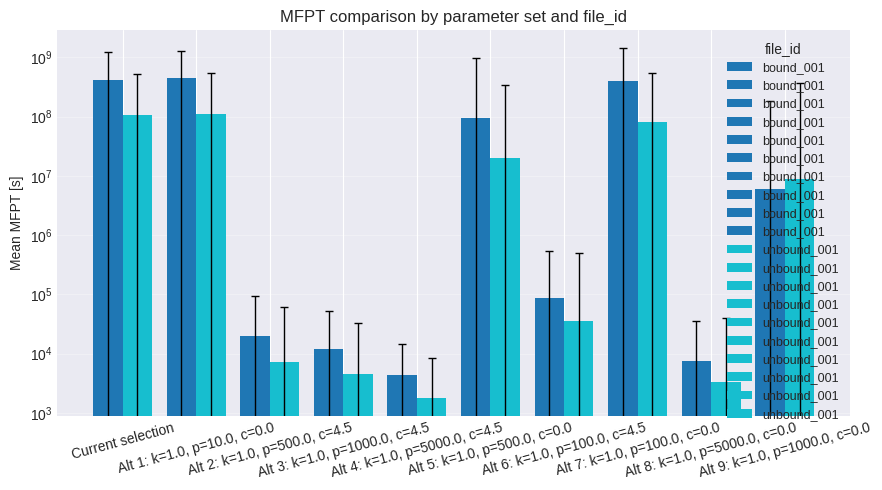

label,"Alt 1: k=1.0, p=10.0, c=0.0","Alt 2: k=1.0, p=500.0, c=4.5","Alt 3: k=1.0, p=1000.0, c=4.5","Alt 4: k=1.0, p=5000.0, c=4.5","Alt 5: k=1.0, p=500.0, c=0.0","Alt 6: k=1.0, p=100.0, c=4.5","Alt 7: k=1.0, p=100.0, c=0.0","Alt 8: k=1.0, p=5000.0, c=0.0","Alt 9: k=1.0, p=1000.0, c=0.0",Current selection,"Δ Alt 2: k=1.0, p=500.0, c=4.5 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Alt 3: k=1.0, p=1000.0, c=4.5 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Alt 4: k=1.0, p=5000.0, c=4.5 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Alt 5: k=1.0, p=500.0, c=0.0 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Alt 6: k=1.0, p=100.0, c=4.5 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Alt 7: k=1.0, p=100.0, c=0.0 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Alt 8: k=1.0, p=5000.0, c=0.0 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Alt 9: k=1.0, p=1000.0, c=0.0 vs Alt 1: k=1.0, p=10.0, c=0.0","Δ Current selection vs Alt 1: k=1.0, p=10.0, c=0.0"
file_id,,,,,,,,,,,,,,,,,,,
bound_001,4.388890e+08,19756.002832,11841.070468,4374.601012,9.382071e+07,86465.669071,4.002507e+08,7580.579145,6.087197e+06,4.098374e+08,-0.999955,-0.999973,-0.999990,-0.786231,-0.999803,-0.088036,-0.999983,-0.986130,-0.066193
unbound_001,1.112527e+08,7346.961746,4460.798676,1769.246441,2.000292e+07,34964.666980,8.136423e+07,3340.961745,8.765932e+06,1.078839e+08,-0.999934,-0.999960,-0.999984,-0.820203,-0.999686,-0.268654,-0.999970,-0.921207,-0.030280


In [17]:
# MFPT comparison table and bar chart
if mfpt_comparison_df.empty:
    print("⚠ No MFPT data available for the chosen parameter sets.")
else:
    display_cols = [
        "label",
        "file_id",
        "directory",
        "n_valid",
        "n_censored",
        "mfpt_mean",
        "mfpt_std",
        "mfpt_mean_phys",
        "mfpt_std_phys",
    ]
    show_cols = [col for col in display_cols if col in mfpt_comparison_df.columns]
    display(mfpt_comparison_df[show_cols].sort_values(["file_id", "label"]))

    labels = list(dict.fromkeys(mfpt_comparison_df["label"]))
    file_ids = sorted(mfpt_comparison_df["file_id"].unique())
    plot_df = mfpt_comparison_df[np.isfinite(mfpt_comparison_df["mfpt_mean_phys"])].copy()

    if plot_df.empty:
        print("⚠ MFPT values could not be converted to physical units (missing k_wrap).")
    else:
        x_positions = np.arange(len(labels), dtype=float)
        bar_width = 0.8 / max(1, len(file_ids))
        color_map = plt.cm.get_cmap("tab10", max(1, len(file_ids)))
        seen = set()

        fig, ax = plt.subplots(figsize=(9, 5))
        for idx, fid in enumerate(file_ids):
            for j, label in enumerate(labels):
                row = plot_df[(plot_df["file_id"] == fid) & (plot_df["label"] == label)]
                if row.empty:
                    continue
                y_val = float(row["mfpt_mean_phys"].iloc[0])
                err_val = row["mfpt_std_phys"].iloc[0]
                xpos = x_positions[j] - 0.4 + bar_width / 2 + idx * bar_width
                bar = ax.bar(xpos, y_val, width=bar_width, color=color_map(idx),
                             label=fid if fid not in seen else None)
                if np.isfinite(err_val) and err_val > 0:
                    ax.errorbar(xpos, y_val, yerr=err_val, fmt="none", ecolor="k", capsize=3, lw=1)
            seen.add(fid)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=15)
        ax.set_ylabel("Mean MFPT [s]")
        ax.set_title("MFPT comparison by parameter set and file_id")
        ax.set_yscale("log")
        ax.grid(True, axis="y", alpha=0.3)
        if seen:
            ax.legend(title="file_id", fontsize=9)
        plt.tight_layout()
        plt.show()

    mfpt_pivot = (
        mfpt_comparison_df
        .pivot_table(index="file_id", columns="label", values="mfpt_mean_phys")
        .sort_index()
    )
    if mfpt_pivot.shape[1] >= 2:
        base_label = mfpt_pivot.columns[0]
        with np.errstate(divide="ignore", invalid="ignore"):
            for col in mfpt_pivot.columns[1:]:
                mfpt_pivot[f"Δ {col} vs {base_label}"] = (mfpt_pivot[col] / mfpt_pivot[base_label]) - 1
        display(mfpt_pivot)
    else:
        print("Add at least two parameter sets to see MFPT deltas.")

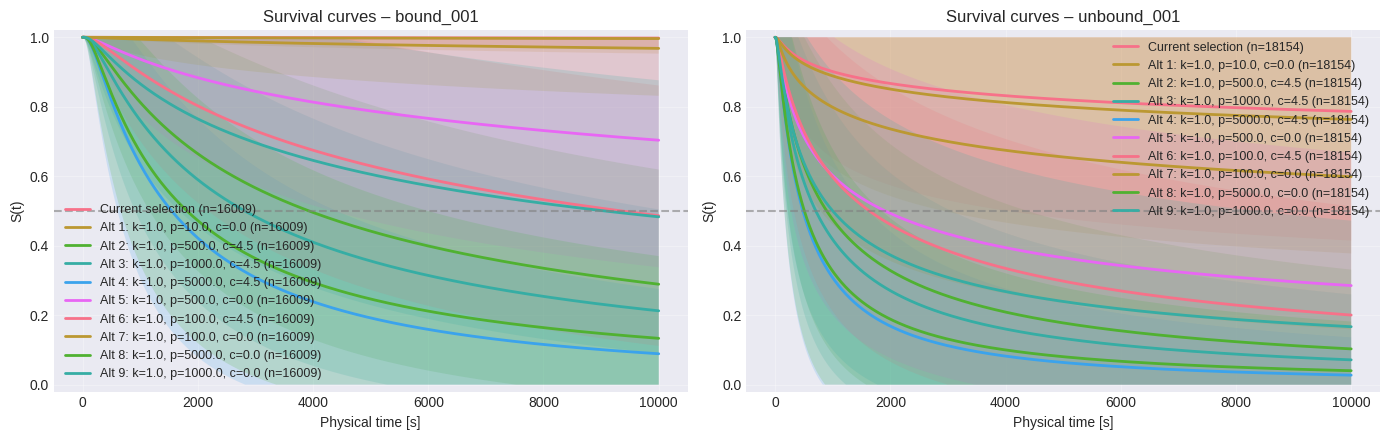

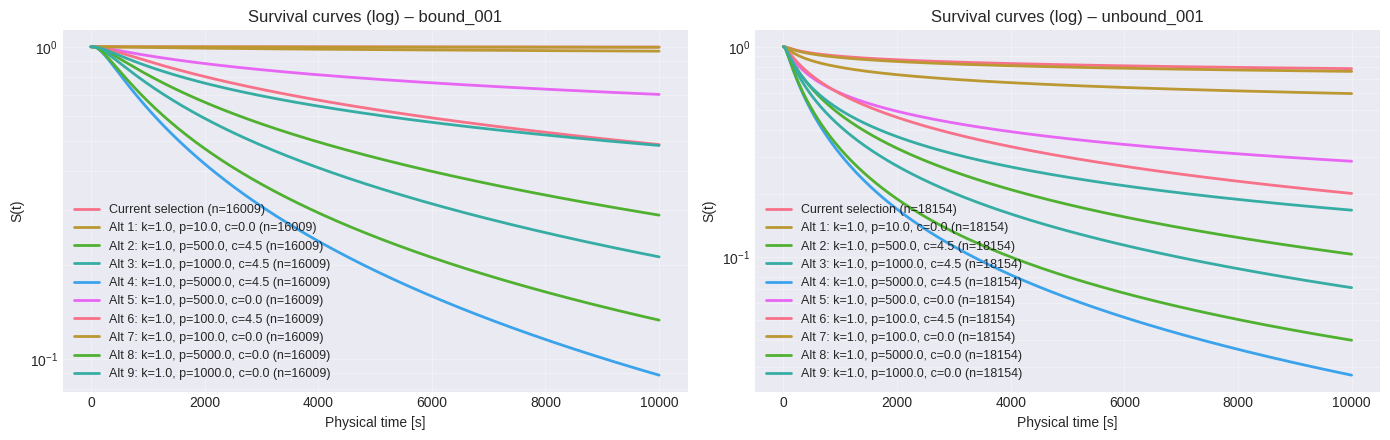


SURVIVAL CURVE COMPARISON SUMMARY


,label,file_id,n_traj,t_half_dimless,t_half_phys,S(t_max),auc_dimless,auc_phys,t_S<=0.1_dimless,t_S<=0.1_phys
2,"Alt 1: k=1.0, p=10.0, c=0.0",bound_001,16009,NaN,NaN,0.996327,9979.179474,9979.179474,NaN,NaN
4,"Alt 2: k=1.0, p=500.0, c=4.5",bound_001,16009,3930.747611,3930.747611,0.289080,5030.009434,5030.009434,NaN,NaN
6,"Alt 3: k=1.0, p=1000.0, c=4.5",bound_001,16009,2816.076930,2816.076930,0.212528,4279.372735,4279.372735,NaN,NaN
8,"Alt 4: k=1.0, p=5000.0, c=4.5",bound_001,16009,1546.705693,1546.705693,0.088856,2832.671465,2832.671465,9069.069069,9069.069069
10,"Alt 5: k=1.0, p=500.0, c=0.0",bound_001,16009,NaN,NaN,0.703670,8078.961205,8078.961205,NaN,NaN
12,"Alt 6: k=1.0, p=100.0, c=4.5",bound_001,16009,9353.179878,9353.179878,0.486274,6671.605715,6671.605715,NaN,NaN
14,"Alt 7: k=1.0, p=100.0, c=0.0",bound_001,16009,NaN,NaN,0.968058,9806.992260,9806.992260,NaN,NaN
16,"Alt 8: k=1.0, p=5000.0, c=0.0",bound_001,16009,1812.652484,1812.652484,0.133315,3305.566852,3305.566852,NaN,NaN
18,"Alt 9: k=1.0, p=1000.0, c=0.0",bound_001,16009,9064.333253,9064.333253,0.483059,6457.431301,6457.431301,NaN,NaN
0,Current selection,bound_001,16009,NaN,NaN,0.997779,9987.623495,9987.623495,NaN,NaN


In [18]:
# Survival curve overlays and quantitative summaries
if not survival_curve_map:
    print("⚠ No survival curve data found for the selected parameter sets.")
else:
    file_ids_surv = sorted({fid for (_, fid) in survival_curve_map.keys()})
    if not file_ids_surv:
        print("⚠ None of the selected directories contain survival curves.")
    else:
        n_plots = len(file_ids_surv)
        ncols = min(2, n_plots)
        nrows = math.ceil(n_plots / ncols)

        def _time_axis(payload: dict, plan: dict) -> tuple[np.ndarray, str]:
            k_val = plan["k_wrap"]
            if np.isfinite(k_val) and k_val > 0:
                return payload["tau_grid"] / k_val, "Physical time [s]"
            return payload["tau_grid"], "Dimensionless time"

        # Linear plots with uncertainty bands
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), squeeze=False)
        axes_flat = axes.ravel()
        for idx, fid in enumerate(file_ids_surv):
            ax = axes_flat[idx]
            for plan in comparison_plan:
                payload = survival_curve_map.get((plan["label"], fid))
                if payload is None:
                    continue
                t_axis, x_label = _time_axis(payload, plan)
                ax.plot(t_axis, payload["mean"], lw=2, label=f"{plan['label']} (n={payload['n']})")
                ax.fill_between(t_axis,
                                np.clip(payload["mean"] - payload["std"], 0, 1),
                                np.clip(payload["mean"] + payload["std"], 0, 1),
                                alpha=0.18)
            ax.axhline(0.5, ls="--", color="gray", alpha=0.6)
            ax.set_title(f"Survival curves – {fid}")
            ax.set_xlabel(x_label)
            ax.set_ylabel("S(t)")
            ax.set_ylim(-0.02, 1.02)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
        for ax in axes_flat[n_plots:]:
            ax.remove()
        plt.tight_layout()
        plt.show()

        # Log-scaled view (no fill to keep it readable)
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), squeeze=False)
        axes_flat = axes.ravel()
        for idx, fid in enumerate(file_ids_surv):
            ax = axes_flat[idx]
            for plan in comparison_plan:
                payload = survival_curve_map.get((plan["label"], fid))
                if payload is None:
                    continue
                t_axis, x_label = _time_axis(payload, plan)
                ax.semilogy(t_axis, payload["mean"] + 1e-12, lw=2, label=f"{plan['label']} (n={payload['n']})")
            ax.set_title(f"Survival curves (log) – {fid}")
            ax.set_xlabel(x_label)
            ax.set_ylabel("S(t)")
            ax.grid(True, which="both", alpha=0.3)
            ax.legend(fontsize=9)
        for ax in axes_flat[n_plots:]:
            ax.remove()
        plt.tight_layout()
        plt.show()

        # Quantitative summary (half-life, area, S(t) thresholds)
        half_life_records = []
        for (label, fid), payload in survival_curve_map.items():
            t_half_dim = half_life(payload["tau_grid"], payload["mean"], level=0.5)
            k_val = payload["k_wrap"]
            entry = {
                "label": label,
                "file_id": fid,
                "n_traj": payload["n"],
                "t_half_dimless": t_half_dim,
                "t_half_phys": (t_half_dim / k_val) if np.isfinite(t_half_dim) and np.isfinite(k_val) and k_val > 0 else np.nan,
                "S(t_max)": payload["mean"][-1],
                "auc_dimless": np.trapezoid(payload["mean"], payload["tau_grid"]),
            }
            if np.isfinite(entry["auc_dimless"]) and np.isfinite(k_val) and k_val > 0:
                entry["auc_phys"] = entry["auc_dimless"] / k_val
            else:
                entry["auc_phys"] = np.nan
            below_idx = np.where(payload["mean"] <= 0.1)[0]
            if below_idx.size:
                t10 = payload["tau_grid"][below_idx[0]]
                entry["t_S<=0.1_dimless"] = t10
                if np.isfinite(k_val) and k_val > 0:
                    entry["t_S<=0.1_phys"] = t10 / k_val
                else:
                    entry["t_S<=0.1_phys"] = np.nan
            else:
                entry["t_S<=0.1_dimless"] = np.nan
                entry["t_S<=0.1_phys"] = np.nan
            half_life_records.append(entry)

        half_life_df = pd.DataFrame(half_life_records)
        if not half_life_df.empty:
            print("\n" + "=" * 80)
            print("SURVIVAL CURVE COMPARISON SUMMARY")
            print("=" * 80)
            display(half_life_df.sort_values(["file_id", "label"]))
        else:
            print("No survival statistics could be computed.")